# Predicting Stock Trends: Rise or Fall?

## Competition Overview

This competition challenges participants to predict whether a stock's closing price will be above or below its current value after 30 trading days. Using OHLC (Open, High, Low, Close) data from 5,000 stocks, participants must build accurate predictive models to identify future stock price trends.

Link: https://www.kaggle.com/competitions/predicting-stock-trends-rise-or-fall

In [13]:
import pandas as pd

train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [7]:
train_df.head(10)

,Ticker,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,ticker_1,1962-01-02,0.000000,0.265828,0.261788,0.261788,25600.0,0.0,0.0
1,ticker_20,1962-01-02,0.000000,0.417455,0.412380,0.414917,84139.0,0.0,0.0
2,ticker_19,1962-01-02,0.000000,0.101537,0.100789,0.100789,902400.0,0.0,0.0
3,ticker_18,1962-01-02,0.000000,0.903030,0.881959,0.881959,51552.0,0.0,0.0
4,ticker_17,1962-01-02,0.130512,0.131783,0.129241,0.130512,163200.0,0.0,0.0
5,ticker_16,1962-01-02,1.574350,1.574350,1.556660,1.556660,407940.0,0.0,0.0
6,ticker_14,1962-01-02,0.000000,0.999724,0.976598,0.976598,5800.0,0.0,0.0
7,ticker_13,1962-01-02,0.190311,0.190311,0.187037,0.187037,352350.0,0.0,0.0
8,ticker_12,1962-01-02,0.000000,1.550548,1.541704,1.541704,55930.0,0.0,0.0
9,ticker_11,1962-01-02,2.609572,2.653065,2.583476,2.600873,432682.0,0.0,0.0


## Data Overview

* Ticker: ticker_1 - ticker_5000
* Columns: 9
* Columns details:
    * **Date**: The date corresponding to the stock data entry.
    * **Open**: Opening price of the stock on that date.
    * **High**: Highest price of the stock on that date.
    * **Low**: Lowest price of the stock on that date.
    * **Close**: Closing price of the stock on that date.
    * **Volume**:  Number of shares traded on that date.
    * **Dividends**: Dividend payout value for that date.
    * **Stock Splits**: Any stock splits that occurred on that date.
    * **Ticker**: The unique identifier for the stock.

In [9]:
test_df.head(10)

,ID,Date
0,ticker_1,2024-11-04
1,ticker_10,2024-11-04
2,ticker_100,2024-11-04
3,ticker_1000,2024-11-04
4,ticker_1001,2024-11-04
5,ticker_1002,2024-11-04
6,ticker_1003,2024-11-04
7,ticker_1004,2024-11-04
8,ticker_1005,2024-11-04
9,ticker_1006,2024-11-04


## EDA

In [11]:
train_df.shape

(21033522, 9)

In [13]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21033522 entries, 0 to 21033521
Data columns (total 9 columns):
 #   Column        Dtype  
---  ------        -----  
 0   Ticker        object 
 1   Date          object 
 2   Open          float64
 3   High          float64
 4   Low           float64
 5   Close         float64
 6   Volume        float64
 7   Dividends     float64
 8   Stock Splits  float64
dtypes: float64(7), object(2)
memory usage: 1.4+ GB


In [15]:
train_df['Date'] = pd.to_datetime(train_df['Date'])

In [16]:
train_df.describe()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,21033522,2.103352e+07,2.103352e+07,2.103352e+07,2.103352e+07,2.103352e+07,2.103352e+07,21033522.0
mean,2010-07-13 05:38:49.608935168,2.285003e+01,2.335000e+01,2.265493e+01,2.300253e+01,1.174856e+06,2.012335e-03,inf
min,1962-01-02 00:00:00,0.000000e+00,7.606973e-02,0.000000e+00,7.425315e-02,0.000000e+00,0.000000e+00,0.0
25%,2003-06-10 00:00:00,4.680000e+00,4.900000e+00,4.727687e+00,4.810000e+00,2.550000e+04,0.000000e+00,0.0
50%,2013-05-06 00:00:00,1.162689e+01,1.189265e+01,1.151079e+01,1.170101e+01,1.452000e+05,0.000000e+00,0.0
75%,2020-02-27 00:00:00,2.584961e+01,2.627552e+01,2.554281e+01,2.591151e+01,6.881000e+05,0.000000e+00,0.0
max,2024-09-23 00:00:00,8.319200e+02,1.010080e+03,4.320597e+02,4.356200e+02,3.565254e+09,1.594000e+02,inf
std,NaN,3.409086e+01,3.457287e+01,3.360952e+01,3.408867e+01,6.574807e+06,8.486632e-02,NaN


### Distribution Plots

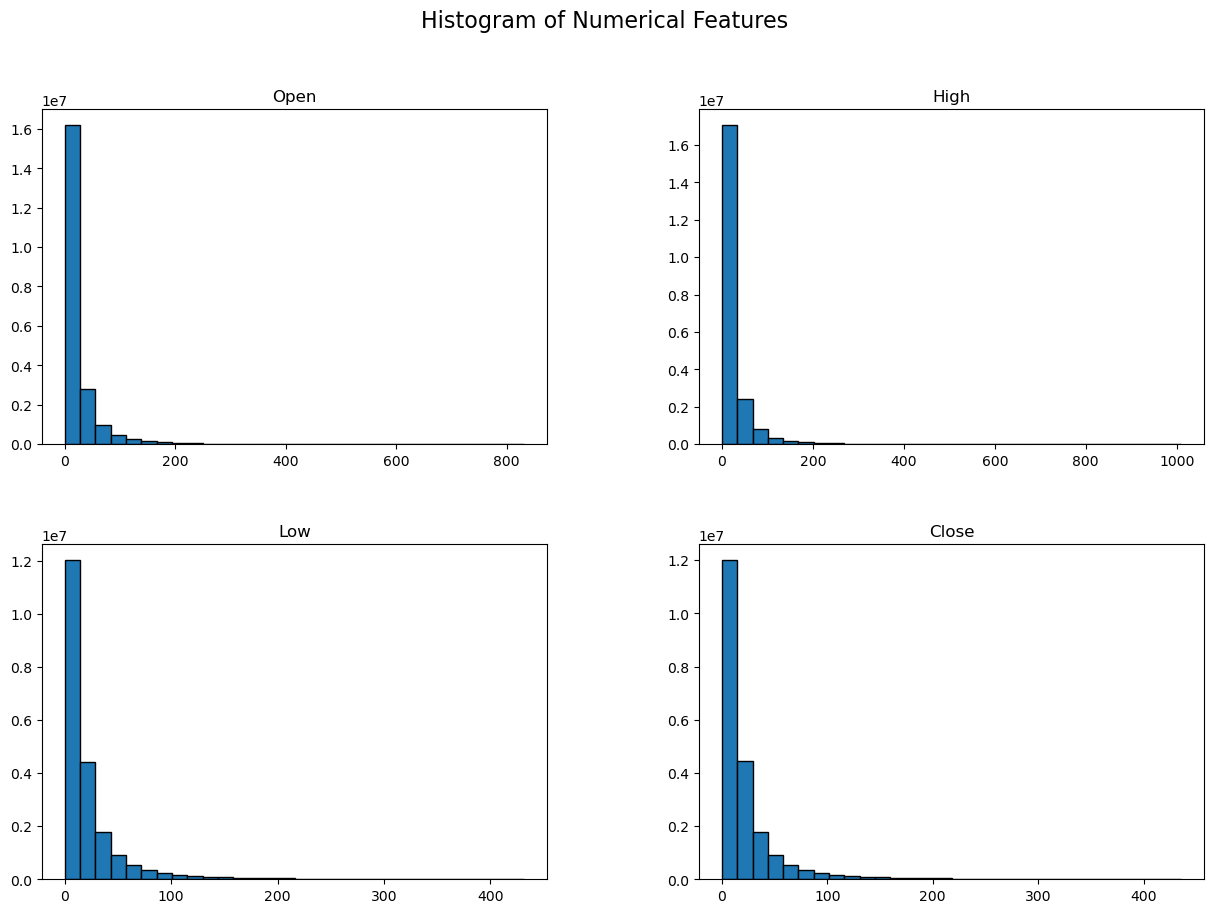

In [33]:
import matplotlib.pyplot as plt
import seaborn as sb
import numpy as np

numeric_cols = train_df[['Open', 'High', 'Low', 'Close']]
numeric_cols.hist(figsize=(15, 10), bins=30, edgecolor="black", grid=False)
plt.suptitle("Histogram of Numerical Features", fontsize=16)
plt.show()
    

## Feature Engineer

In [19]:
train_df['Ticker'].value_counts()

Ticker
ticker_1       15789
ticker_9       15789
ticker_20      15789
ticker_10      15789
ticker_2       15789
               ...  
ticker_4995      232
ticker_4997      231
ticker_4998      229
ticker_4999      225
ticker_5000      224
Name: count, Length: 5000, dtype: int64

In [20]:
# sort by ticker number and date
train_df = train_df.sort_values(['Ticker', 'Date'])

In [21]:
train_df.head()

,Ticker,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,ticker_1,1962-01-02,0.0,0.265828,0.261788,0.261788,25600.0,0.0,0.0
25,ticker_1,1962-01-03,0.0,0.263808,0.261788,0.261788,28800.0,0.0,0.0
49,ticker_1,1962-01-04,0.0,0.263404,0.260980,0.260980,21600.0,0.0,0.0
76,ticker_1,1962-01-05,0.0,0.259364,0.255324,0.255324,46400.0,0.0,0.0
97,ticker_1,1962-01-08,0.0,0.259364,0.255728,0.256536,29600.0,0.0,0.0


In [22]:
train_df.tail()

,Ticker,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
21010467,ticker_999,2024-09-17,87.059998,88.120003,87.059998,87.709999,997900.0,0.0,0.0
21014125,ticker_999,2024-09-18,87.720001,87.959999,86.680000,86.870003,757100.0,0.0,0.0
21019828,ticker_999,2024-09-19,88.220001,89.089996,87.680000,88.800003,885900.0,0.0,0.0
21026462,ticker_999,2024-09-20,89.019997,90.070000,88.610001,89.910004,1665400.0,0.0,0.0
21032385,ticker_999,2024-09-23,90.070000,90.239998,89.480003,89.989998,569600.0,0.0,0.0


### Create target feature

In [23]:
# creating the target feature 1 if close after 30 days is higher or 0 if is less
train_df['Target'] = (train_df.groupby('Ticker')['Close'].shift(-30) > train_df['Close']).astype(int)

### Create Tecnical Features

* Close lags and retunrs:
    * This shows the previuos close values and close presentages per day and week and it can be use to analize micro-movements and weekly trends.
* Moving average:
    * Average of the last values, that keeps changing with the time pass, this can be use to identify trends.
* Gradients:
    * This measures how quickly the price changes over time. It can help to identify the direction of the trend or identify critical points.

In [25]:
# creating lag features
train_df['Close_lag_1'] = train_df.groupby('Ticker')['Close'].shift(1)
train_df['Close_lag_7'] = train_df.groupby('Ticker')['Close'].shift(7)

In [27]:
# creating return features
train_df['Return_1'] = train_df.groupby('Ticker')['Close'].pct_change(1)
train_df['Return_7'] = train_df.groupby('Ticker')['Close'].pct_change(7)

In [28]:
# creating SMA feature
train_df['SMA_10'] = train_df.groupby('Ticker')['Close'].transform(lambda x: x.rolling(window=10).mean())
train_df['SMA_30'] = train_df.groupby('Ticker')['Close'].transform(lambda x: x.rolling(window=30).mean())

In [32]:
import numpy as np
# creatin gradients features
train_df['Grad_30'] = train_df.groupby('Ticker')['Close'].transform(lambda x: np.gradient(x, 30))

In [33]:
train_df['Grad_200'] = train_df.groupby('Ticker')['Close'].transform(lambda x: np.gradient(x, 200))

In [35]:
# creating grad indicator
train_df['Grad_30_ind'] = (train_df['Grad_30'] < 0).astype(int)
train_df['Grad_200_ind'] = (train_df['Grad_200'] > 0).astype(int)

In [36]:
train_df.head(10)

,Ticker,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Target,Close_lag_1,Close_lag_7,Return_1,Return_7,SMA_10,SMA_30,Grad_30,Grad_200,Grad_30_ind,Grad_200_ind
0,ticker_1,1962-01-02,0.0,0.265828,0.261788,0.261788,25600.0,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0,0
25,ticker_1,1962-01-03,0.0,0.263808,0.261788,0.261788,28800.0,0.0,0.0,0,0.261788,NaN,0.000000,NaN,NaN,NaN,-0.000013,-0.000002,1,0
49,ticker_1,1962-01-04,0.0,0.263404,0.260980,0.260980,21600.0,0.0,0.0,1,0.261788,NaN,-0.003086,NaN,NaN,NaN,-0.000108,-0.000016,1,0
76,ticker_1,1962-01-05,0.0,0.259364,0.255324,0.255324,46400.0,0.0,0.0,1,0.260980,NaN,-0.021673,NaN,NaN,NaN,-0.000074,-0.000011,1,0
97,ticker_1,1962-01-08,0.0,0.259364,0.255728,0.256536,29600.0,0.0,0.0,1,0.255324,NaN,0.004747,NaN,NaN,NaN,0.000013,0.000002,0,1
113,ticker_1,1962-01-09,0.0,0.259364,0.256132,0.256132,40000.0,0.0,0.0,1,0.256536,NaN,-0.001575,NaN,NaN,NaN,-0.000020,-0.000003,1,0
129,ticker_1,1962-01-10,0.0,0.257748,0.242396,0.255324,20800.0,0.0,0.0,1,0.256132,NaN,-0.003155,NaN,NaN,NaN,0.000007,0.000001,0,1
144,ticker_1,1962-01-11,0.0,0.257748,0.255728,0.256536,25600.0,0.0,0.0,0,0.255324,0.261788,0.004747,-0.020062,NaN,NaN,0.000054,0.000008,0,1
171,ticker_1,1962-01-12,0.0,0.259364,0.256132,0.258556,16000.0,0.0,0.0,0,0.256536,0.261788,0.007874,-0.012346,NaN,NaN,0.000047,0.000007,0,1
198,ticker_1,1962-01-15,0.0,0.259364,0.257748,0.259364,34400.0,0.0,0.0,0,0.258556,0.260980,0.003125,-0.006193,0.258232,NaN,-0.000047,-0.000007,1,0


In [38]:
train_df.tail()

,Ticker,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Target,Close_lag_1,Close_lag_7,Return_1,Return_7,SMA_10,SMA_30,Grad_30,Grad_200,Grad_30_ind,Grad_200_ind
21010467,ticker_999,2024-09-17,87.059998,88.120003,87.059998,87.709999,997900.0,0.0,0.0,0,86.879997,82.330002,0.009553,0.065347,84.388999,84.112333,-0.000167,-0.000025,1,0
21014125,ticker_999,2024-09-18,87.720001,87.959999,86.680000,86.870003,757100.0,0.0,0.0,0,87.709999,83.019997,-0.009577,0.046374,84.770999,84.309666,0.018167,0.002725,0,1
21019828,ticker_999,2024-09-19,88.220001,89.089996,87.680000,88.800003,885900.0,0.0,0.0,0,86.870003,82.889999,0.022217,0.071299,85.353999,84.596000,0.050667,0.007600,0,1
21026462,ticker_999,2024-09-20,89.019997,90.070000,88.610001,89.910004,1665400.0,0.0,0.0,0,88.800003,84.349998,0.012500,0.065916,86.112000,84.882667,0.019833,0.002975,0,1
21032385,ticker_999,2024-09-23,90.070000,90.239998,89.480003,89.989998,569600.0,0.0,0.0,0,89.910004,85.129997,0.000890,0.057089,86.809000,85.163667,0.002666,0.000400,0,1


In [46]:
# dropping nan rows
fit_train = train_df.dropna()

In [47]:
fit_train.head()

,Ticker,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Target,Close_lag_1,Close_lag_7,Return_1,Return_7,SMA_10,SMA_30,Grad_30,Grad_200,Grad_30_ind,Grad_200_ind
595,ticker_1,1962-02-12,0.0,0.251320,0.250096,0.251320,22400.0,0.0,0.0,1,0.251320,0.251320,0.000000,0.000000,0.251156,0.253733,0.000061,0.000009,0,1
614,ticker_1,1962-02-13,0.0,0.256216,0.250912,0.254992,36000.0,0.0,0.0,1,0.251320,0.251320,0.014611,0.014611,0.251524,0.253506,0.000122,0.000018,0,1
639,ticker_1,1962-02-14,0.0,0.258663,0.255807,0.258663,41600.0,0.0,0.0,1,0.254992,0.251320,0.014400,0.029220,0.252340,0.253402,0.000116,0.000017,0,1
640,ticker_1,1962-02-15,0.0,0.261927,0.258663,0.261927,38400.0,0.0,0.0,1,0.258663,0.250912,0.012619,0.043902,0.253400,0.253434,-0.000007,-0.000001,1,0
668,ticker_1,1962-02-16,0.0,0.261927,0.257848,0.258256,38400.0,0.0,0.0,1,0.261927,0.252136,-0.014018,0.024273,0.254094,0.253531,-0.000048,-0.000007,1,0


## Data Spliting

### Using all features

In [52]:
features_col = ['Close_lag_1', 'Close_lag_7', 'Return_1', 'Return_7', 'SMA_10', 'SMA_30', 'Grad_30_ind', 'Grad_200_ind']

In [54]:
from sklearn.model_selection import train_test_split

# data spliting
x =  fit_train[features_col]
y = fit_train['Target']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(f"Size of training data: {x_train.shape[0]}")
print(f"Size of test data: {x_test.shape[0]}")

Size of training data: 16710817
Size of test data: 4177705


### Using only Gradients indicators

In [56]:
# trying only with gradients features
grad_feat = ['Grad_30_ind', 'Grad_200_ind']

x = fit_train[grad_feat]
y = fit_train['Target']

x_train_grad, x_test_grad, y_train_grad, y_test_grad = train_test_split(x, y, test_size=0.2, random_state=42)
print(f"Size of training data: {x_train.shape[0]}")
print(f"Size of test data: {x_test.shape[0]}")

Size of training data: 16710817
Size of test data: 4177705


## Model Training (Random Forest Classifier)

### Random Forest using all the features

In [61]:
from sklearn.ensemble import RandomForestClassifier

# random forest classifier
rf = RandomForestClassifier(n_estimators=50, max_depth=10)
rf.fit(x_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=50)

In [62]:
y_pred = rf.predict(x_test)

In [63]:
from sklearn.metrics import accuracy_score, classification_report

# accuracy score
print(f"Accuracy score of Random Forest Classifier: {accuracy_score(y_test, y_pred)}")

# classification report
target_names = ['Lower', 'Higher']
print(classification_report(y_test, y_pred, target_names=target_names))

Accuracy score of Random Forest Classifier: 0.555599785049447
              precision    recall  f1-score   support

       Lower       0.54      0.26      0.35   1938937
      Higher       0.56      0.81      0.66   2238768

    accuracy                           0.56   4177705
   macro avg       0.55      0.54      0.51   4177705
weighted avg       0.55      0.56      0.52   4177705



### Random Forest using Gradient Features

In [68]:
# random forest classifier
rf_grad = RandomForestClassifier(n_estimators=50, max_depth=10)
rf_grad.fit(x_train_grad, y_train_grad)

RandomForestClassifier(max_depth=10, n_estimators=50)

In [69]:
y_pred_grad = rf_grad.predict(x_test_grad)

In [70]:
# accuracy score
print(f"Accuracy score of Random Forest Classifier: {accuracy_score(y_test_grad, y_pred_grad)}")

# classification report
target_names = ['Lower', 'Higher']
print(classification_report(y_test_grad, y_pred_grad, target_names=target_names))

Accuracy score of Random Forest Classifier: 0.5382146417710202
              precision    recall  f1-score   support

       Lower       0.50      0.50      0.50   1938937
      Higher       0.57      0.58      0.57   2238768

    accuracy                           0.54   4177705
   macro avg       0.54      0.54      0.54   4177705
weighted avg       0.54      0.54      0.54   4177705



#### Obervations:

The model using all features achieved a slightly better score than the one using only gradient features. However, since the difference is minimal, the final submission will include both models.

## Making the submission

In [76]:
# create features for test data
sub = train_df.sort_values(by=['Date']).groupby(by=['Ticker']).tail(1)

In [77]:
sub = sub.sort_values(by=['Ticker'])

In [78]:
# combine_df.head()
sub.head()

,Ticker,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Target,Close_lag_1,Close_lag_7,Return_1,Return_7,SMA_10,SMA_30,Grad_30,Grad_200,Grad_30_ind,Grad_200_ind
21031592,ticker_1,2024-09-23,103.680000,104.440002,103.290001,104.019997,1053600.0,0.0,0.0,0,103.349998,103.389999,0.006483,0.006093,103.903000,102.259333,0.022333,0.00335,0,1
21033461,ticker_10,2024-09-23,174.009995,175.190002,172.589996,173.770004,10265000.0,0.0,0.0,0,174.220001,173.470001,-0.002583,0.001729,174.583000,172.020666,-0.015000,-0.00225,1,0
21032419,ticker_100,2024-09-23,254.509995,256.929993,253.029999,256.649994,716200.0,0.0,0.0,0,254.320007,248.199997,0.009162,0.034045,252.629001,247.533001,0.077666,0.01165,0,1
21030232,ticker_1000,2024-09-23,52.980000,53.279999,52.389999,52.980000,30500.0,0.0,0.0,0,52.340000,51.369999,0.012228,0.031341,52.227000,52.127666,0.021333,0.00320,0,1
21033276,ticker_1001,2024-09-23,20.190001,20.350000,20.059999,20.290001,284600.0,0.0,0.0,0,19.969999,20.379999,0.016024,-0.004416,20.184000,20.291667,0.010667,0.00160,0,1


### Submission using all features

In [83]:
# predict using all features
x_test = sub[features_col]
predict=rf.predict(x_test)

In [85]:
submission = pd.DataFrame({
    'ID': sub['Ticker'],
    'Pred': predict
})

submission.to_csv('submission_using_all_feat.csv', index=False)

### Submission using Gradient Features

In [90]:
# predict using gradiants
x_test_pred = sub[grad_feat]
predict = rf_grad.predict(x_test_pred)

In [92]:
submission = pd.DataFrame({
    'ID': sub['Ticker'],
    'Pred': predict
})

submission.to_csv('submission_using_Grad.csv', index=False)